# K-Nearest neighbours

1. you move to new city and waant to decide whether a resturant is good ?

2. How?

3. Check reviews

4. Ask nearby people 

5. see what friend recommendation 

6. KNN also ask its nearest neighbours before making prediction 

# What is KNN ?

K - nearest neighbours (KNN) is a supervised machine learning algorithm

- Used for :

    - Classification 

    - Regression 
    
    - it predict the output by looking at the K nearest dats points.

- **Example**:

- A new student Join a class.

    - Nearby student:

        - A -> Science

        - B -> Science

        - C -> Commerce

        - predict -> Science 

- **Example** :

   - movie Recommendation 

        - Himank -> Action

        - Mihika -> Thriller

        - Shaurya -> Action

        - Saurabh -> Action



# Where KNN is Used:

- Email spam detection

- Disease Prediction

- Student will pass or not 

- Banking ( Credit Approval )

- Face recognition

# Types of Problems solved

- 1. Classification:

        - output is category

        - ex ->>> spam or not spam

        - cancer or No cancer

        - male or female

- 2. Regression:

        - Output is continous value 
    
        - Ex -> House Price 

        - Salary Prediction

        - Temperature Predict

- 3. Why ??

        - Suppose there is a new point
         
        - There are many old data point

        - the closed one 

        - Because nearby objects usually have similar properties

- 4. Distance Measure ......!!!!

        - Eucludian

        - d = sqrt((x2 - x1)^2 + (y2 - y1)^2)

        - Point A - (2,3)
    
        - Point B - (5,7)

        - Distance = sqrt((5-2)^2 + (7-3)^2) = 9 + 16 = 25 => 5

- 5. Manhattan Distance 

        - Like walking on roads

        - can not move diagonally

        - Form = | x2 - x1 | + | y2 - y1 |

- 6. Hamming Distance 

        - Used for Categorical Data

        - Binary Data

        - Ex -> 101110 ->> 10011

        - Different bits = Hamming distance 


- 3. K means Number of nearest neighbours

      - K = 3 : Look at nearest 3 neighbours
       
      - K = 5 : Look at nearest 5 neighbours

- Example :

    - suppose : red, red, black, K = 3

    - majority : red 
     
    - Predict : red
         

- 4. Choosing K ?

     - small k :

     - Advantage : sensitive, captures local pattern 

     - Disadvantage : Overfitting , Noise affects prediction

- Large k : 

      - Advantage : Stable, Less noise
        
      - Disadvantages : Underfitting

- IMP : Goldden Rules 

- K = Underroot(N)

- N : Number of Samples 

- Example : 100 samples = √N = √100 = 10

- K = 10, then use cross validation to choose the best k

# Working

1. Choosing k

2. Calculate Distance 

3. Find K nearest neighbours

4. Voting 

5. Predict our class

- Suppose k = 3 

- Neighbour : A 

- Neighbour : B

- Neighbour : A 

- Neighbour : C

- Predict : A 

2. Neighbours : Cat 

- Neighbours : Dog

- Neighbours : Dog

- Predict : Dog

# Dataset 

- Height : 160, 165, 170, 180, 185

- Weight : 55, 60, 65, 90, 95

- Class : fit, fit, fit, unfit, unfit

- New person : 

- Height is 172

- Weight 68

- Class ? fit ya unfit ?

- Predict : Fit

# Feature Scalling ? 

- Age : 20 

- Salary : 800000

- Which feature dominates

- Salary 

- Therefore always scale data before KNN

# KNN Lazy learner ya fast learner ? or then why ?

- Because it does not learn during training

- It stores data and predicts only when a new sample arrives 

# KNN

- Lazy learner, it does not required training, and it works on distance based so lsow prediction


# Logistic Regression

- Eager learner, it required a training and it is based on probability and fast doing fast prediction 

# Practicle :

#### Import libraries 

#### Load dataset

#### Train_test_split

#### feature scaling 

#### Create model 

#### train model 

#### predict through our test data

#### evaluate model ( accuracy, precision, recall, classification_report)

#### new sample predict

#### find best k value

In [175]:
import numpy as np # numerical operations
import pandas as pd # Data manipulation 
import matplotlib.pyplot as plt # visualization 
import seaborn as sns # visualization 

In [176]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [177]:
cancer = load_breast_cancer()

In [178]:
df = pd.DataFrame(
    cancer.data,
    columns= cancer.feature_names
)

In [179]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [180]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [181]:
df['Target'] = cancer.target

In [182]:
print(df['Target'].value_counts())

Target
1    357
0    212
Name: count, dtype: int64


In [183]:
X = df.drop('Target', axis=1) # Independent variable
y = df['Target'] # Dependent varible

In [184]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.25,random_state = 40, stratify=y
)

In [185]:
X_train.shape

(426, 30)

In [186]:
X_test.shape

(143, 30)

In [187]:
scaler = StandardScaler()

In [188]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [189]:
knn = KNeighborsClassifier(n_neighbors=5)
knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [190]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [191]:
pred = knn.predict(X_test)

In [192]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    'Predicted': pred
})

In [193]:
comparison.head(5)

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,0,0
4,1,1


In [194]:
accuracy = accuracy_score(y_test,pred)
accuracy

0.986013986013986

In [195]:
precision = precision_score(y_test,pred) # correct positive prediction
precision

0.9782608695652174

In [196]:
recall = recall_score(y_test, pred) # Actual positive correctly identified.
recall

1.0

In [197]:
f1 = f1_score(y_test,pred)# Balance btw precision and recall
f1

0.989010989010989

In [198]:
cm = confusion_matrix(y_test, pred)

In [199]:
print(cm)

[[51  2]
 [ 0 90]]


In [200]:
# Plot Confusion Matrix

plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

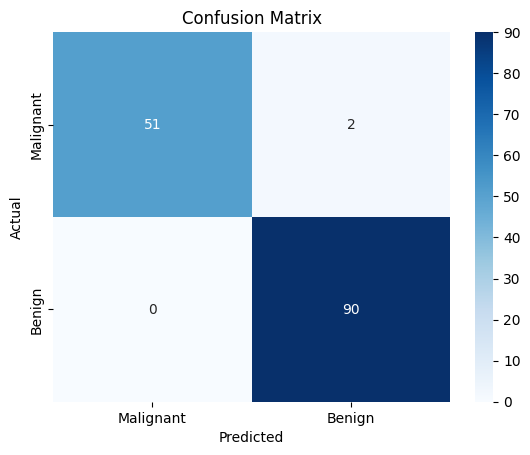

In [201]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [202]:
report = classification_report(y_test, pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        53
           1       0.98      1.00      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.98       143
weighted avg       0.99      0.99      0.99       143



In [203]:
sample = X.iloc[[0]]
sam = scaler.transform(sample)
prediction = knn.predict(sam)

print("Predicted Class:", prediction[0])
print("Actual Class: ", y.iloc[0])

Predicted Class: 0
Actual Class:  0


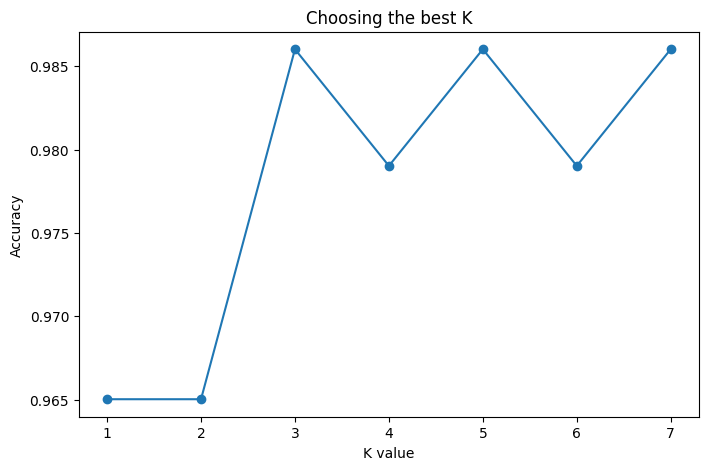

In [204]:
acc_score = []
for k in range(1,8):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    prediction = model.predict(X_test)
    score = accuracy_score(y_test,prediction)
    acc_score.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(1,8),acc_score,marker='o' )
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Choosing the best K")
plt.show()

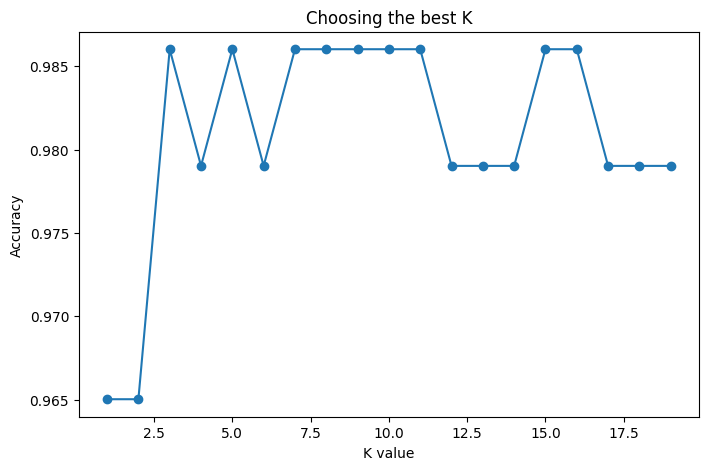

In [205]:
acc_score = []
for k in range(1,20):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    prediction = model.predict(X_test)
    score = accuracy_score(y_test,prediction)
    acc_score.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(1,20),acc_score,marker='o' )
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Choosing the best K")
plt.show()

# Practical 

### DataSet : iris

In [206]:
from sklearn.datasets import load_iris

iris = load_iris()

In [207]:
df2 = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

In [208]:
df2["target"] = iris.target

In [209]:
df2.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [210]:
print("shape:", df2.shape)

shape: (150, 5)


In [211]:
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [212]:
print(df2.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [213]:
print(df2['target'].value_counts())

target
0    50
1    50
2    50
Name: count, dtype: int64


In [214]:
X = df2.drop('target', axis=1) # Independent variable
y = df2['target'] # Dependent variable 

In [215]:
print(df2['target'].value_counts())

target
0    50
1    50
2    50
Name: count, dtype: int64


In [216]:
X_tr, X_ts, y_tr, y_ts = train_test_split(
    X,y,test_size=0.25,random_state = 40, stratify=y
)

In [217]:
X_tr.shape

(112, 4)

In [218]:
X_ts.shape

(38, 4)

In [219]:
scaler = StandardScaler()

X_tr = scaler.fit_transform(X_tr)
X_ts = scaler.transform(X_ts)

In [220]:
knn = KNeighborsClassifier(n_neighbors=7)
knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [221]:
knn.fit(X_tr, y_tr)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [222]:
pre = knn.predict(X_ts)

In [223]:
pre = knn.predict(X_ts)
comparison = pd.DataFrame({
    "Actual": y_ts.values,
    "Predicted": pre
})

In [224]:
accuracy = accuracy_score(y_ts,pre)
accuracy

0.9736842105263158

In [225]:
cm2 = confusion_matrix(y_ts,pre)
print(cm2)

[[12  0  0]
 [ 0 13  0]
 [ 0  1 12]]


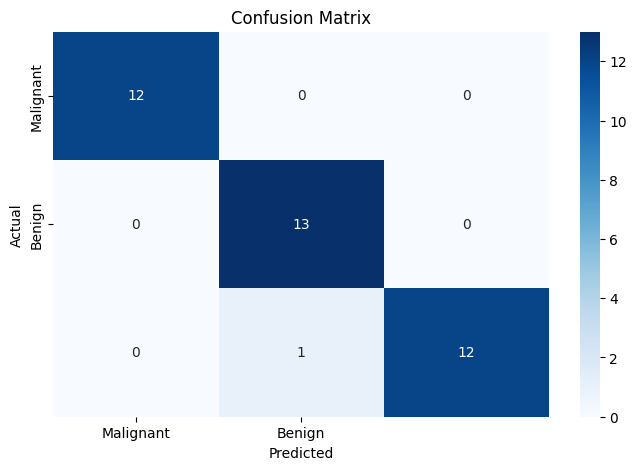

In [226]:
plt.figure(figsize=(8,5))

sns.heatmap(cm2, annot=True, fmt="d", cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [227]:
print(classification_report(y_ts,pre))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [228]:
sample = X.iloc[[0]]
sam = scaler.transform(sample)
predict = knn.predict(sam)

print("Predicted Class:", prediction[0])
print("Actual Class:", y.iloc[0])

Predicted Class: 1
Actual Class: 0


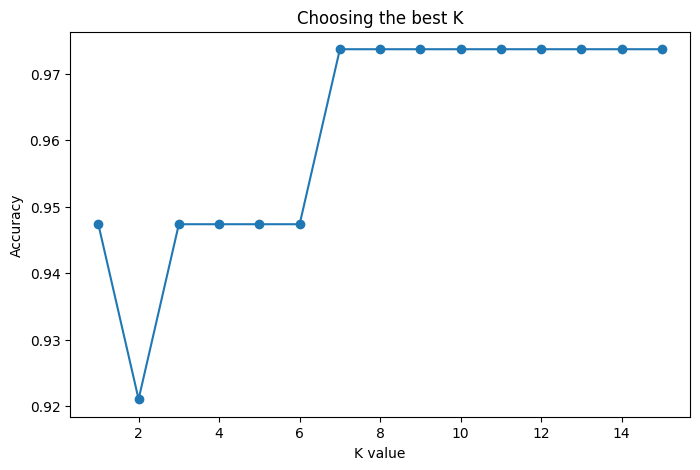

In [229]:
acc_score = []
for k in range(1,16):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_tr,y_tr)
    predict = model.predict(X_ts)
    score = accuracy_score(y_ts,predict)
    acc_score.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(1,16),acc_score,marker='o' )
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Choosing the best K")
plt.show()